# Simulation and parameter recovery of dynamic foraging task.

In [1]:
pip install -e /root/capsule

Obtaining file:///root/capsule
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for aind-dynamic-foraging-models (pyproject.toml) ... done
  Created wheel for aind-dynamic-foraging-models: filename=aind_dynamic_foraging_models-0.13.0-0.editable-py3-none-any.whl size=6692 sha256=dd7d2135685bcd2eae018602b460f77349e832555eec35b243492493e3b7b4c8
  Stored in directory: /tmp/pip-ephem-wheel-cache-jiyfc04n/wheels/e3/8f/f4/ca91d283f9cf1779655f765432c0871dffb626f70fabd09288
Successfully built aind-dynamic-foraging-models
  Attempting uninstall: aind-dynamic-foraging-models
    Found existing installation: aind-dynamic-foraging-models 0.13.0
    Uninstalling aind-dynamic-foraging-models-0.13.0:
      Successfully uninstalled aind-dynamic-foraging-models-0.13.0
Note: you may need to restart the kernel to use updated pack

In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from aind_behavior_gym.dynamic_foraging.task import CoupledBlockTask, UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model import ForagerCollection

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get all foragers

In [7]:
from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection


forager_collection: ForagerCollection = ForagerCollection()
df = forager_collection.get_all_foragers()
df.columns

Index(['agent_class_name', 'agent_kwargs', 'agent_alias',
       'number_of_learning_rate', 'number_of_forget_rate', 'choice_kernel',
       'action_selection', 'preset_name', 'n_free_params', 'params', 'forager',
       'win_stay_lose_switch', 'reset_to_threshold', 'include_stay_bias',
       'include_side_bias', 'fix_threshold'],
      dtype='object')

In [8]:
df

,agent_class_name,agent_kwargs,agent_alias,number_of_learning_rate,number_of_forget_rate,choice_kernel,action_selection,preset_name,n_free_params,params,forager,win_stay_lose_switch,reset_to_threshold,include_stay_bias,include_side_bias,fix_threshold
0,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_softmax,1.0,0.0,none,softmax,None,3,"$\alpha$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
1,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_epsi,1.0,0.0,none,epsilon-greedy,Rescorla-Wagner,3,"$\alpha$, $b_L$, $\epsilon$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
2,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_softmax,1.0,0.0,one_step,softmax,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
3,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_epsi,1.0,0.0,one_step,epsilon-greedy,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
4,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CKfull_softmax,1.0,0.0,full,softmax,None,5,"$\alpha$, $\alpha_{ck}$, $w_{ck}$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,7,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,True,False,False
122,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,5,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,True,True
123,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,6,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,True,False
124,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,5,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,False,True


In [9]:
df.agent_alias[55]

'ForagingCompareThreshold_L1_CK1_ResetF_StayBiasT_SideBiasT_FixThrF'

## Parameter Recovery

2026-03-04 06:19:32,206 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...


=== Ground-truth generator ===
agent_alias: ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_SideBiasT_FixThrF
agent_kwargs: {'number_of_learning_rate': 2, 'choice_kernel': 'none', 'reset_to_threshold': False, 'include_stay_bias': True, 'include_side_bias': True, 'fix_threshold': False, 'threshold_fixed': None}
ParamModel fields: ['biasL', 'learn_rate_rew', 'learn_rate_unrew', 'softmax_inverse_temperature', 'stay_bias', 'threshold']
Applied ground-truth params: {'softmax_inverse_temperature': 10.0, 'biasL': 3.0, 'threshold': 0.0, 'learn_rate_rew': 0.32, 'learn_rate_unrew': 0.24, 'stay_bias': 1.5}
params_list_free: ['learn_rate_rew', 'stay_bias', 'learn_rate_unrew', 'biasL', 'threshold', 'softmax_inverse_temperature']
params: {'learn_rate_rew': 0.32, 'learn_rate_unrew': 0.24, 'threshold': 0.0, 'softmax_inverse_temperature': 10.0, 'biasL': 3.0, 'stay_bias': 1.5}

Fitting variant: L1 | reset_to_threshold=True
differential_evolution step 1: f(x)= 83.19147227379929
differential_evolution

2026-03-04 06:19:49,774 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L1 | reset_to_threshold=False
differential_evolution step 1: f(x)= 80.07223686556134
differential_evolution step 2: f(x)= 80.07223686556134
differential_evolution step 3: f(x)= 80.07223686556134
differential_evolution step 4: f(x)= 75.50792556122404
differential_evolution step 5: f(x)= 75.50792556122404
differential_evolution step 6: f(x)= 75.50792556122404
differential_evolution step 7: f(x)= 72.04718923197109
differential_evolution step 8: f(x)= 72.04718923197109
differential_evolution step 9: f(x)= 72.04718923197109
differential_evolution step 10: f(x)= 72.04718923197109
differential_evolution step 11: f(x)= 72.04718923197109
differential_evolution step 12: f(x)= 71.51437874981545
differential_evolution step 13: f(x)= 71.51437874981545
differential_evolution step 14: f(x)= 71.33908496917785
differential_evolution step 15: f(x)= 70.96831823894377
differential_evolution step 16: f(x)= 70.96831823894377
differential_evolution step 17: f(x)= 70.96831823894377
different

2026-03-04 06:20:06,802 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L2 | reset_to_threshold=True
differential_evolution step 1: f(x)= 75.35320437868315
differential_evolution step 2: f(x)= 75.35320437868315
differential_evolution step 3: f(x)= 75.35320437868315
differential_evolution step 4: f(x)= 73.6138071258959
differential_evolution step 5: f(x)= 73.6138071258959
differential_evolution step 6: f(x)= 73.6138071258959
differential_evolution step 7: f(x)= 73.25129415479164
differential_evolution step 8: f(x)= 73.25129415479164
differential_evolution step 9: f(x)= 73.25129415479164
differential_evolution step 10: f(x)= 73.25129415479164
differential_evolution step 11: f(x)= 73.25129415479164
differential_evolution step 12: f(x)= 72.08610798685665
differential_evolution step 13: f(x)= 71.60978156741805
differential_evolution step 14: f(x)= 71.60978156741805
differential_evolution step 15: f(x)= 71.47736539048674
differential_evolution step 16: f(x)= 71.40685944757766
differential_evolution step 17: f(x)= 71.40685944757766
differential_

2026-03-04 06:20:37,885 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L2 | reset_to_threshold=False
differential_evolution step 1: f(x)= 75.32701400175117
differential_evolution step 2: f(x)= 75.32701400175117
differential_evolution step 3: f(x)= 75.32701400175117
differential_evolution step 4: f(x)= 75.32701400175117
differential_evolution step 5: f(x)= 75.32701400175117
differential_evolution step 6: f(x)= 75.32701400175117
differential_evolution step 7: f(x)= 74.921135446608
differential_evolution step 8: f(x)= 74.03260080027128
differential_evolution step 9: f(x)= 72.95537630386502
differential_evolution step 10: f(x)= 72.92687207765478
differential_evolution step 11: f(x)= 72.27641361362572
differential_evolution step 12: f(x)= 72.08716828318826
differential_evolution step 13: f(x)= 72.08716828318826
differential_evolution step 14: f(x)= 72.08716828318826
differential_evolution step 15: f(x)= 71.65781015864172
differential_evolution step 16: f(x)= 71.20512425247847
differential_evolution step 17: f(x)= 71.20512425247847
differentia

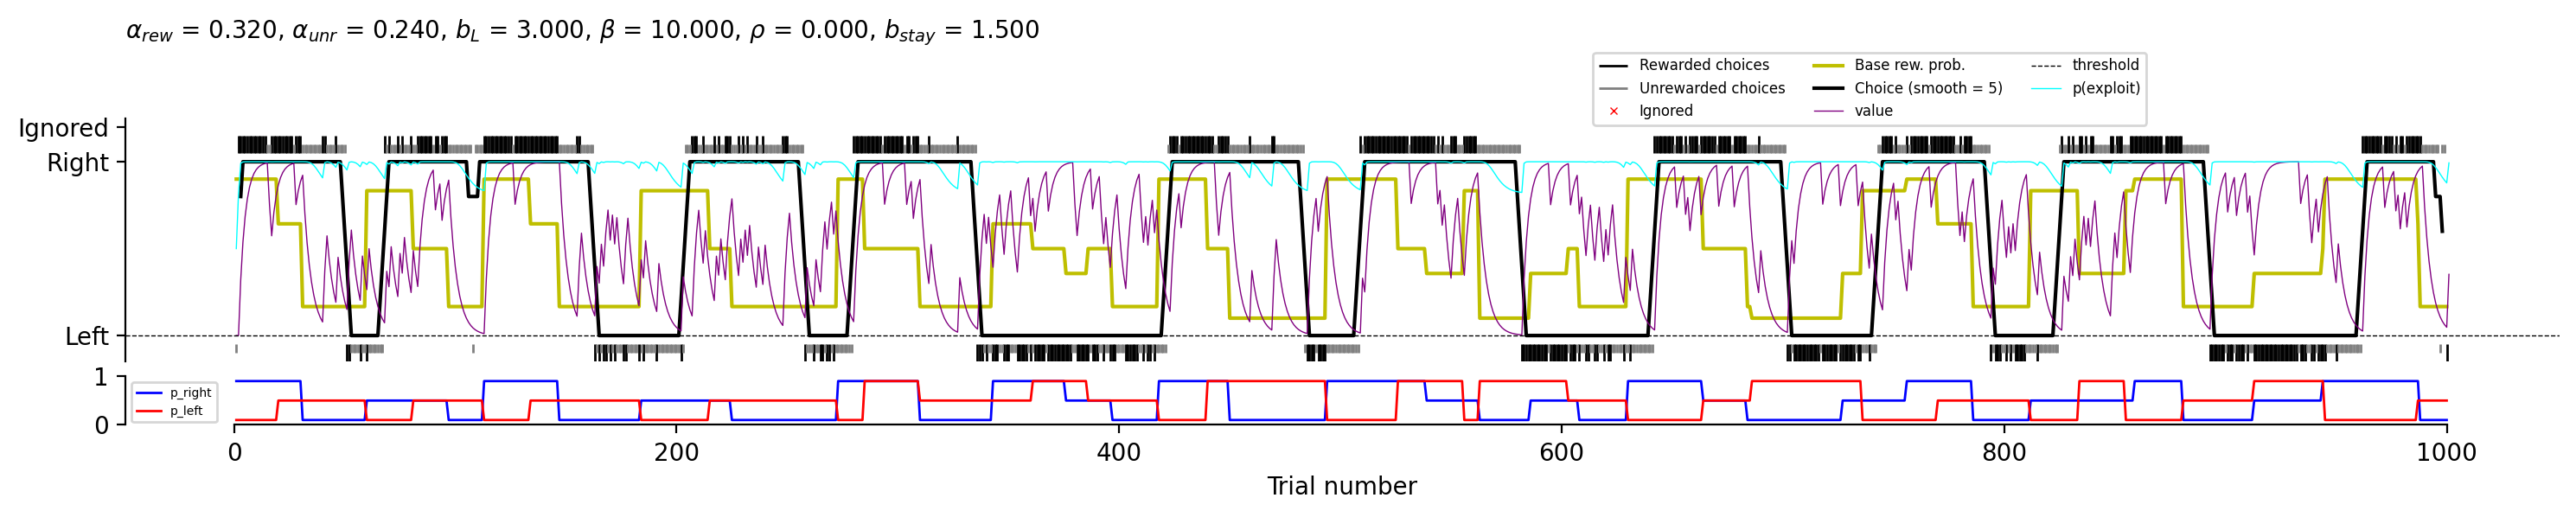

In [16]:
"""
Compare model-recovery across variants of ForagerCompareThreshold.

Updates in this version:
- Add include_side_bias hyperparameter into agent_kwargs (default True in this script)
- Set the ground-truth side bias robustly:
    - Use the exact side-bias parameter name(s) that exist in ParamModel
    - Prefer 'biasL' if it exists; otherwise try common alternatives
    - If none exist, raise an error (so bias is guaranteed to be applied)
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from aind_behavior_gym.dynamic_foraging.task.uncoupled_block_task import UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection


# -----------------------------
# Agent builders / helpers
# -----------------------------
def _build_ctt_agent(
    *,
    number_of_learning_rate: int,
    reset_to_threshold: bool,
    choice_kernel: str = "none",
    include_stay_bias: bool = False,
    include_side_bias: bool = True,   # NEW
    fix_threshold: bool = False,
    threshold_fixed: float | None = None,
    seed: int = 42,
):
    """Build a CompareToThreshold agent with explicit agent_kwargs (hyperparameters)."""
    fc = ForagerCollection()
    preset = fc.FORAGER_PRESETS["CompareToThreshold"]
    agent_class_name = preset["agent_class"]

    agent_kwargs = dict(preset["agent_kwargs"])  # copy
    agent_kwargs.update(
        dict(
            number_of_learning_rate=number_of_learning_rate,
            reset_to_threshold=reset_to_threshold,
            choice_kernel=choice_kernel,
            include_stay_bias=bool(include_stay_bias),
            include_side_bias=bool(include_side_bias),  # NEW
            fix_threshold=bool(fix_threshold),
            threshold_fixed=(float(threshold_fixed) if threshold_fixed is not None else None),
        )
    )

    agent = fc.get_forager(agent_class_name, agent_kwargs=agent_kwargs, seed=seed)
    return agent


def _param_fields(agent) -> set[str]:
    """Return valid parameter field names for agent.set_params(...) (Pydantic v2)."""
    mf = getattr(agent.ParamModel, "model_fields", None)
    if isinstance(mf, dict):
        return set(mf.keys())
    return set(agent.params.model_dump().keys())


def _set_params_if_exist(agent, param_dict: dict) -> dict:
    """
    Filter param_dict to only valid fields, call agent.set_params, and return filtered dict.
    """
    fields = _param_fields(agent)
    filtered = {k: v for k, v in param_dict.items() if k in fields}
    agent.set_params(**filtered)
    return filtered


def _resolve_side_bias_key_or_raise(agent) -> str:
    """
    Find the side-bias parameter key in ParamModel.
    Prefer 'biasL' if present; otherwise try common alternatives.
    Raise if none exist (so GT bias is guaranteed to be applied).
    """
    fields = _param_fields(agent)
    candidates = ["biasL", "side_bias", "bias_left", "bias", "biasR", "choice_bias", "sideBias"]
    for k in candidates:
        if k in fields:
            return k
    raise ValueError(
        "No side-bias parameter found in ParamModel fields. "
        f"Fields={sorted(list(fields))}. "
        "You need to check the preset / ParamModel to find the correct bias key."
    )


def _set_ground_truth_params(
    agent,
    *,
    threshold=0.2,
    beta=10.0,
    biasL=3.0,
    lr_rew=0.32,
    lr_unrew=0.24,
    lr=0.28,
    stay_bias=0.0,
):
    """
    Set ground-truth parameters depending on model structure.

    - Automatically handles L1 vs L2 learning-rate structure.
    - Automatically adds stay_bias only if include_stay_bias=True.
    - Automatically skips threshold if fix_threshold=True.
    - GUARANTEES side bias is applied by using the correct ParamModel key (or raising).
    """
    n_lr = int(agent.agent_kwargs.get("number_of_learning_rate", 1))
    include_stay_bias = bool(agent.agent_kwargs.get("include_stay_bias", False))
    fix_threshold = bool(agent.agent_kwargs.get("fix_threshold", False))

    param_dict: dict = dict(
        softmax_inverse_temperature=float(beta),
    )

    # Side bias: set via the correct ParamModel key (guaranteed)
    side_bias_key = _resolve_side_bias_key_or_raise(agent)
    param_dict[side_bias_key] = float(biasL)

    # Threshold
    if not fix_threshold:
        param_dict["threshold"] = float(threshold)
    else:
        agent.agent_kwargs["threshold_fixed"] = float(threshold)

    # Learning rate structure
    if n_lr == 1:
        param_dict["learn_rate"] = float(lr)
    elif n_lr == 2:
        param_dict["learn_rate_rew"] = float(lr_rew)
        param_dict["learn_rate_unrew"] = float(lr_unrew)
    else:
        raise ValueError(f"number_of_learning_rate must be 1 or 2, got {n_lr}")

    # Stay bias
    if include_stay_bias:
        param_dict["stay_bias"] = float(stay_bias)

    applied = _set_params_if_exist(agent, param_dict)

    # Extra safety: confirm bias actually applied
    if side_bias_key not in applied:
        raise RuntimeError(
            f"Expected side bias key '{side_bias_key}' to be applied, but it was not. "
            f"Applied={applied}"
        )

    return applied


def _fit_agent_on_data(
    *,
    number_of_learning_rate: int,
    reset_to_threshold: bool,
    include_stay_bias: bool,
    include_side_bias: bool,   # NEW
    fix_threshold: bool,
    choice_history,
    reward_history,
    seed: int = 42,
    workers: int = 4,
    threshold_fixed: float | None = None,
):
    """Fit one variant to the same dataset and return summary dict + fitted agent."""
    if fix_threshold and (threshold_fixed is None):
        threshold_fixed = 0.4

    agent = _build_ctt_agent(
        number_of_learning_rate=number_of_learning_rate,
        reset_to_threshold=reset_to_threshold,
        include_stay_bias=include_stay_bias,
        include_side_bias=include_side_bias,  # NEW
        fix_threshold=fix_threshold,
        threshold_fixed=threshold_fixed,
        seed=seed,
    )

    agent.fit(
        choice_history,
        reward_history,
        clamp_params={},
        DE_kwargs=dict(
            workers=workers,
            disp=True,
            seed=np.random.default_rng(seed),
        ),
        k_fold_cross_validation=None,
    )

    fr = agent.fitting_result
    fit_names = fr.fit_settings["fit_names"]
    fitted = dict(zip(fit_names, fr.x))

    return dict(
        number_of_learning_rate=number_of_learning_rate,
        reset_to_threshold=reset_to_threshold,
        include_stay_bias=include_stay_bias,
        include_side_bias=include_side_bias,  # NEW
        fix_threshold=fix_threshold,
        threshold_fixed=threshold_fixed,
        agent_alias=agent.get_agent_alias(),
        fit_names=fit_names,
        fitted_params=fitted,
        LPT=float(fr.LPT),
        prediction_accuracy=float(fr.prediction_accuracy),
        agent=agent,
    )


# =============================================================================
# 1) Generate ONE synthetic dataset from a chosen ground-truth variant
# =============================================================================

GT_number_of_learning_rate = 2
GT_reset_to_threshold = False
GT_include_stay_bias = True
GT_include_side_bias = True   # NEW
GT_fix_threshold = False

task = UncoupledBlockTask(
    reward_baiting=False,
    num_trials=1000,
    seed=53,
)

forager_gen = _build_ctt_agent(
    number_of_learning_rate=GT_number_of_learning_rate,
    reset_to_threshold=GT_reset_to_threshold,
    include_stay_bias=GT_include_stay_bias,
    include_side_bias=GT_include_side_bias,   # NEW
    fix_threshold=GT_fix_threshold,
    threshold_fixed=(0.0 if GT_fix_threshold else None),
    seed=42,
)

applied_gt = _set_ground_truth_params(
    forager_gen,
    threshold=0.0,
    beta=10.0,
    biasL=3.0,     # <-- this value will be applied to the correct side-bias key
    lr_rew=0.32,
    lr_unrew=0.24,
    lr=0.15,
    stay_bias=1.5,
)

print("=== Ground-truth generator ===")
print("agent_alias:", forager_gen.get_agent_alias())
print("agent_kwargs:", forager_gen.agent_kwargs)
print("ParamModel fields:", sorted(list(_param_fields(forager_gen))))
print("Applied ground-truth params:", applied_gt)
print("params_list_free:", forager_gen.params_list_free)
print("params:", forager_gen.params.model_dump())

# Run generator
forager_gen.perform(task)

# Plot generator session
fig_gen, axes_gen = forager_gen.plot_session(if_plot_latent=True)

choice_history = forager_gen.get_choice_history()
reward_history = forager_gen.get_reward_history()

thr_fixed_val = forager_gen.agent_kwargs.get("threshold_fixed", None)
if thr_fixed_val is not None:
    gt_threshold_for_fixed = float(thr_fixed_val)
else:
    gt_threshold_for_fixed = float(forager_gen.params.model_dump().get("threshold", 0.4))

# =============================================================================
# 2) Fit variants to the SAME dataset
# =============================================================================

variants = [
    dict(number_of_learning_rate=1, reset_to_threshold=True,  include_stay_bias=True, include_side_bias=True, fix_threshold=True),
    dict(number_of_learning_rate=1, reset_to_threshold=False, include_stay_bias=True, include_side_bias=True, fix_threshold=True),
    dict(number_of_learning_rate=2, reset_to_threshold=True,  include_stay_bias=True, include_side_bias=True, fix_threshold=True),
    dict(number_of_learning_rate=2, reset_to_threshold=False, include_stay_bias=True, include_side_bias=True, fix_threshold=True),
]

results = []
for v in variants:
    print("\n" + "=" * 80)
    print(f"Fitting variant: L{v['number_of_learning_rate']} | reset_to_threshold={v['reset_to_threshold']}")

    thr_fixed = gt_threshold_for_fixed if v["fix_threshold"] else None

    out = _fit_agent_on_data(
        number_of_learning_rate=v["number_of_learning_rate"],
        reset_to_threshold=v["reset_to_threshold"],
        include_stay_bias=v["include_stay_bias"],
        include_side_bias=v["include_side_bias"],
        fix_threshold=v["fix_threshold"],
        threshold_fixed=thr_fixed,
        choice_history=choice_history,
        reward_history=reward_history,
        seed=42,
        workers=4,
    )
    results.append(out)

df = pd.DataFrame(
    [
        dict(
            agent_alias=r["agent_alias"],
            LPT=r["LPT"],
            prediction_accuracy=r["prediction_accuracy"],
            fit_names=r["fit_names"],
        )
        for r in results
    ]
)
print("\n=== Fit summary ===")
print(df.sort_values("LPT", ascending=False).to_string(index=False))


================ GROUND TRUTH ================

Ground-truth agent: ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_SideBiasT_FixThrF
Ground-truth params: {'learn_rate_rew': 0.32, 'learn_rate_unrew': 0.24, 'threshold': 0.0, 'softmax_inverse_temperature': 10.0, 'stay_bias': 1.5, 'biasL': 3.0}
Ground-truth agent_kwargs: {'number_of_learning_rate': 2, 'choice_kernel': 'none', 'reset_to_threshold': False, 'include_stay_bias': True, 'include_side_bias': True, 'fix_threshold': False, 'threshold_fixed': None}



--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasT_SideBiasT_FixThrT0.00

--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L1_CKnone_ResetF_StayBiasT_SideBiasT_FixThrT0.00

--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareT

,agent_alias,number_of_learning_rate,reset_to_threshold,LPT,prediction_accuracy,Fit_biasL,Fit_learn_rate,Fit_learn_rate_rew,Fit_learn_rate_unrew,Fit_softmax_inverse_temperature,Fit_stay_bias
0,GROUND_TRUTH,2,False,NaN,NaN,3.000000,NaN,0.320000,0.240000,10.000000,1.500000
1,ForagingCompareThreshold_L2_CKnone_ResetF_Stay...,2,False,0.931952,0.976,-0.434828,NaN,0.419869,0.197340,10.310897,0.458416
2,ForagingCompareThreshold_L1_CKnone_ResetF_Stay...,1,False,0.931689,0.976,-0.399018,0.263178,NaN,NaN,16.284957,0.898244
3,ForagingCompareThreshold_L2_CKnone_ResetT_Stay...,2,True,0.931528,0.976,-0.457019,NaN,0.334935,0.237251,12.569259,0.889852
4,ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,1,True,0.931459,0.976,-0.436014,0.261350,NaN,NaN,15.971650,0.994143


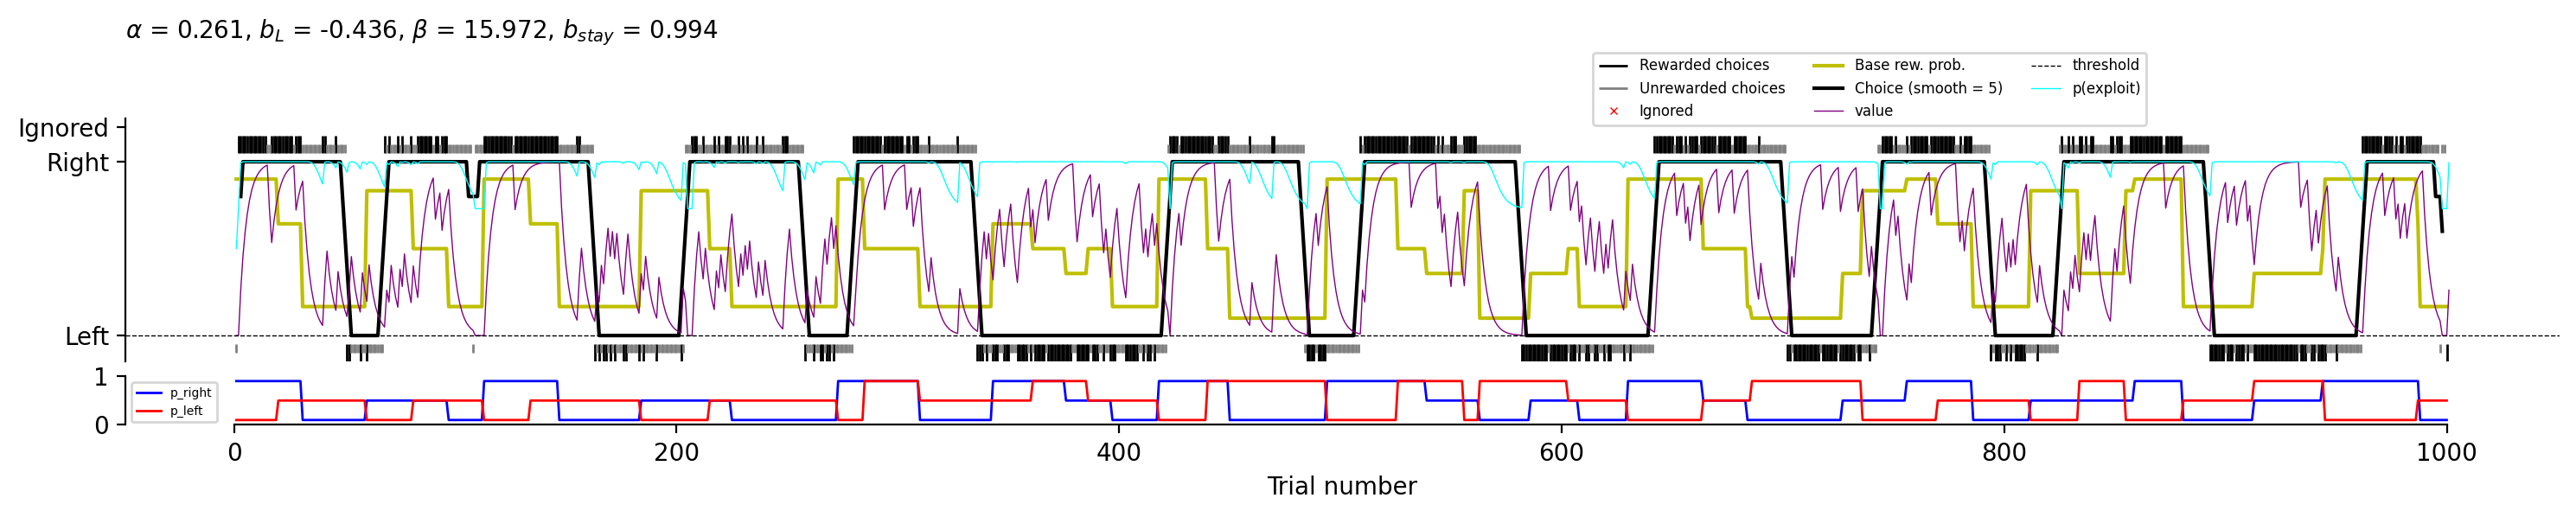

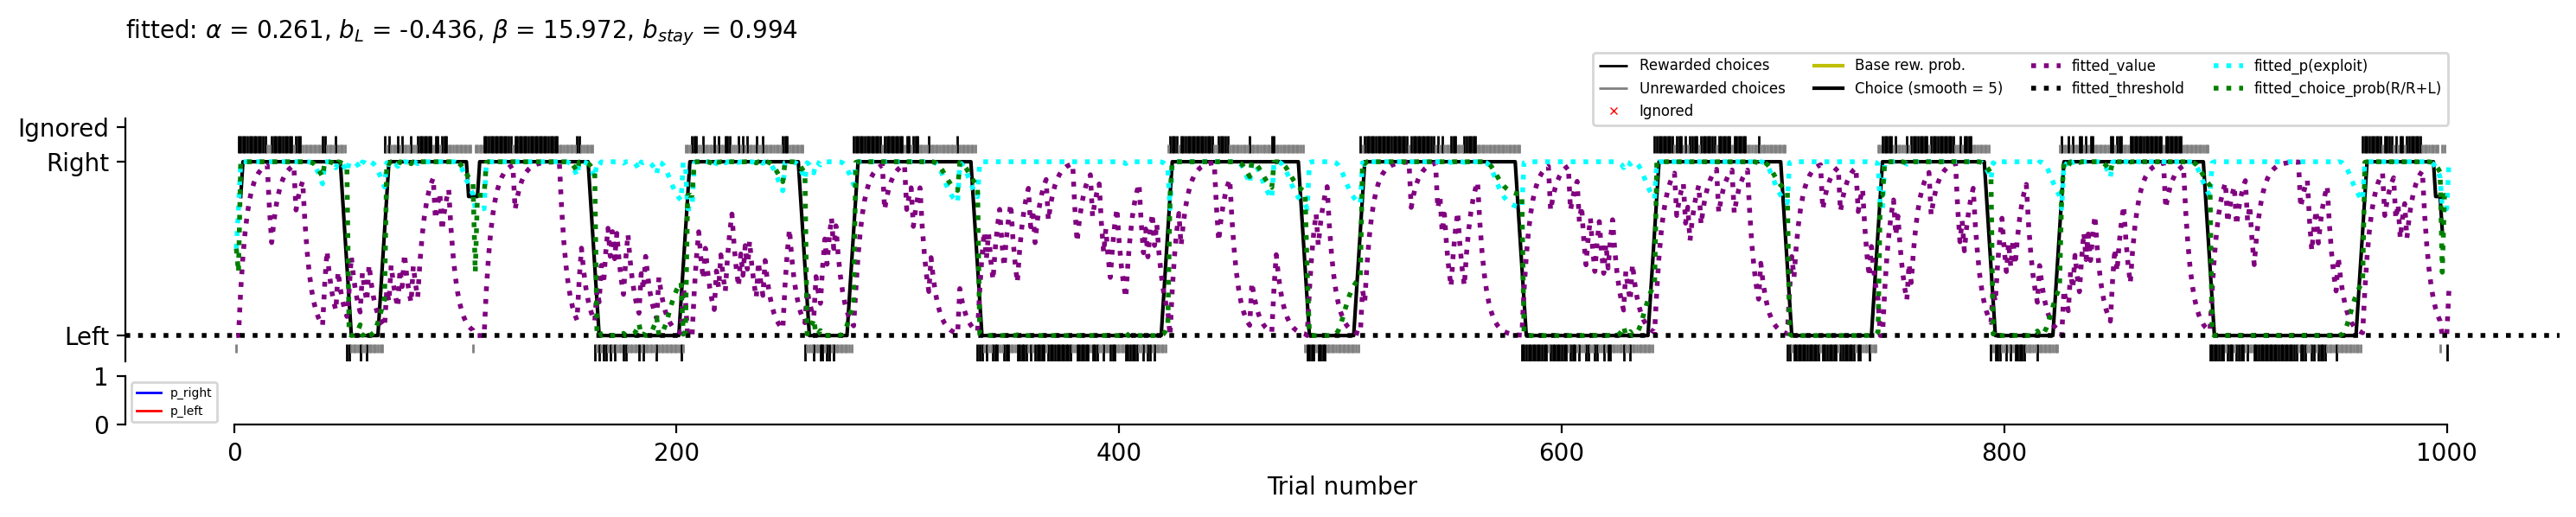

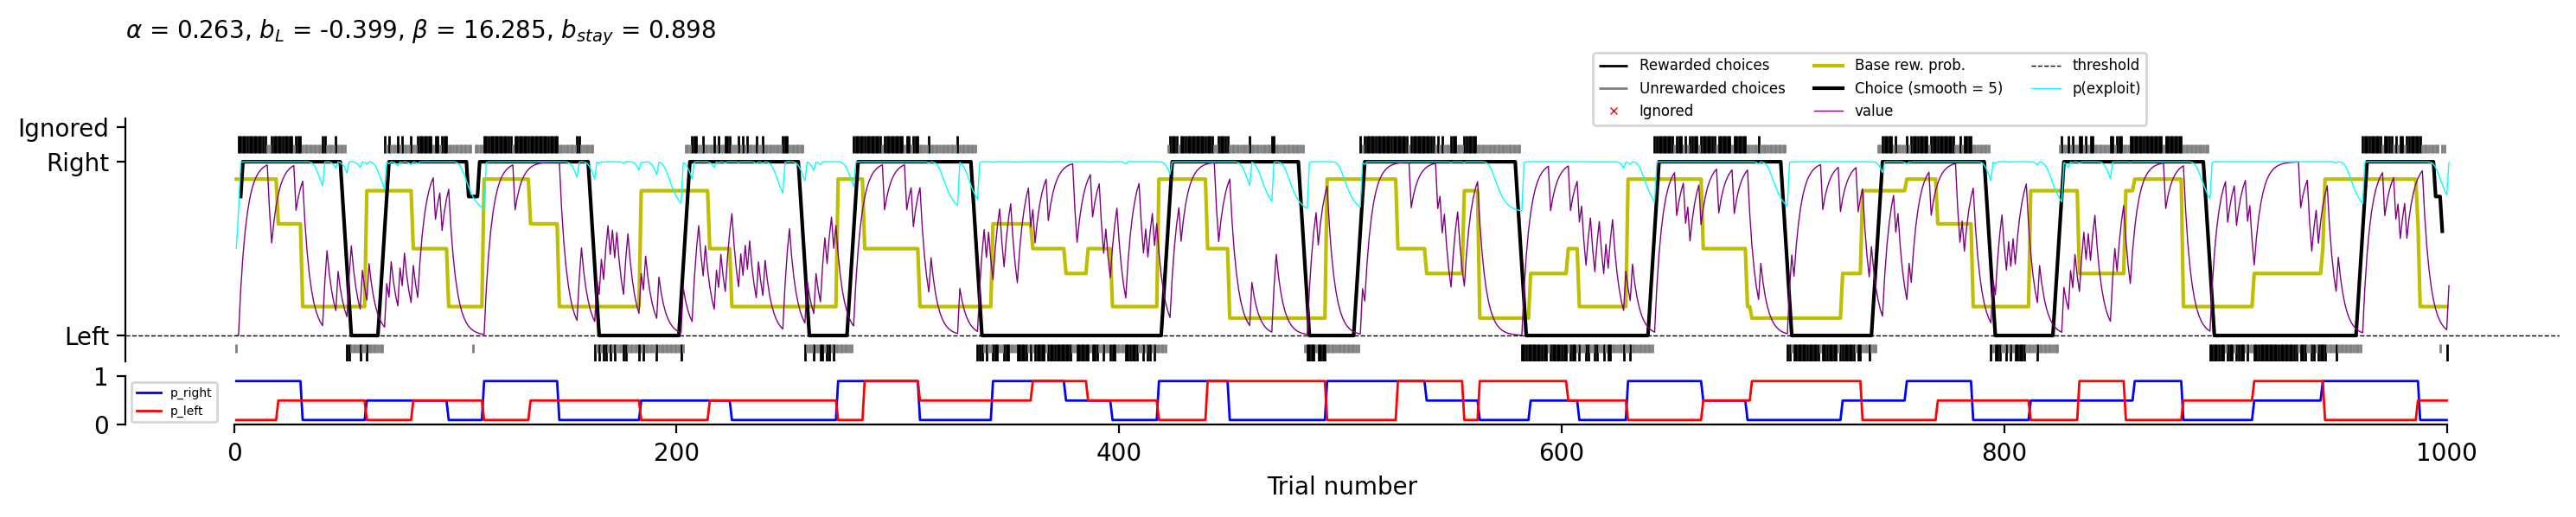

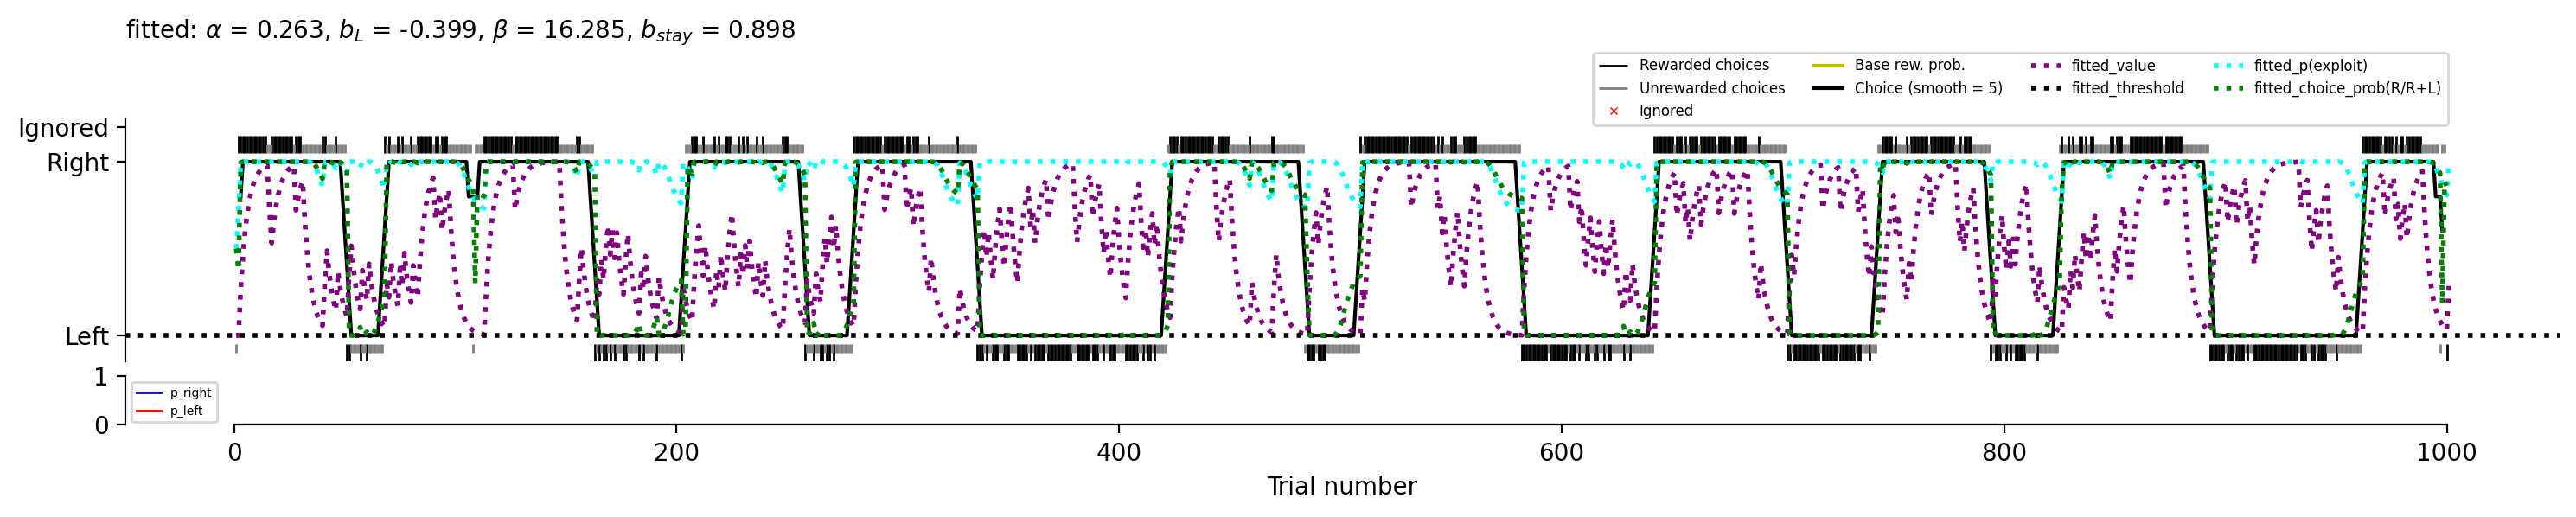

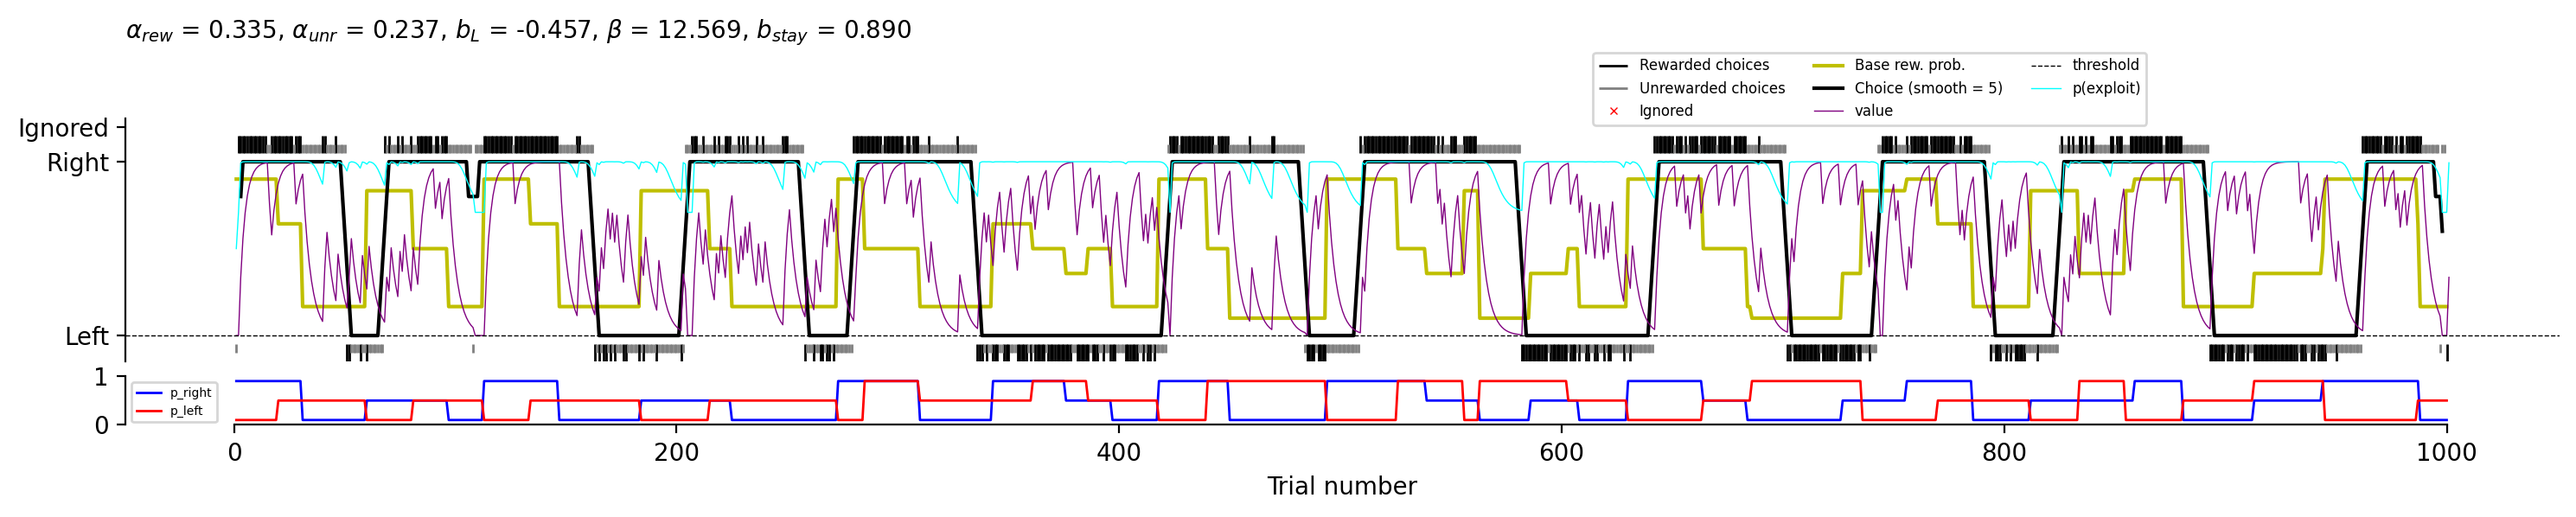

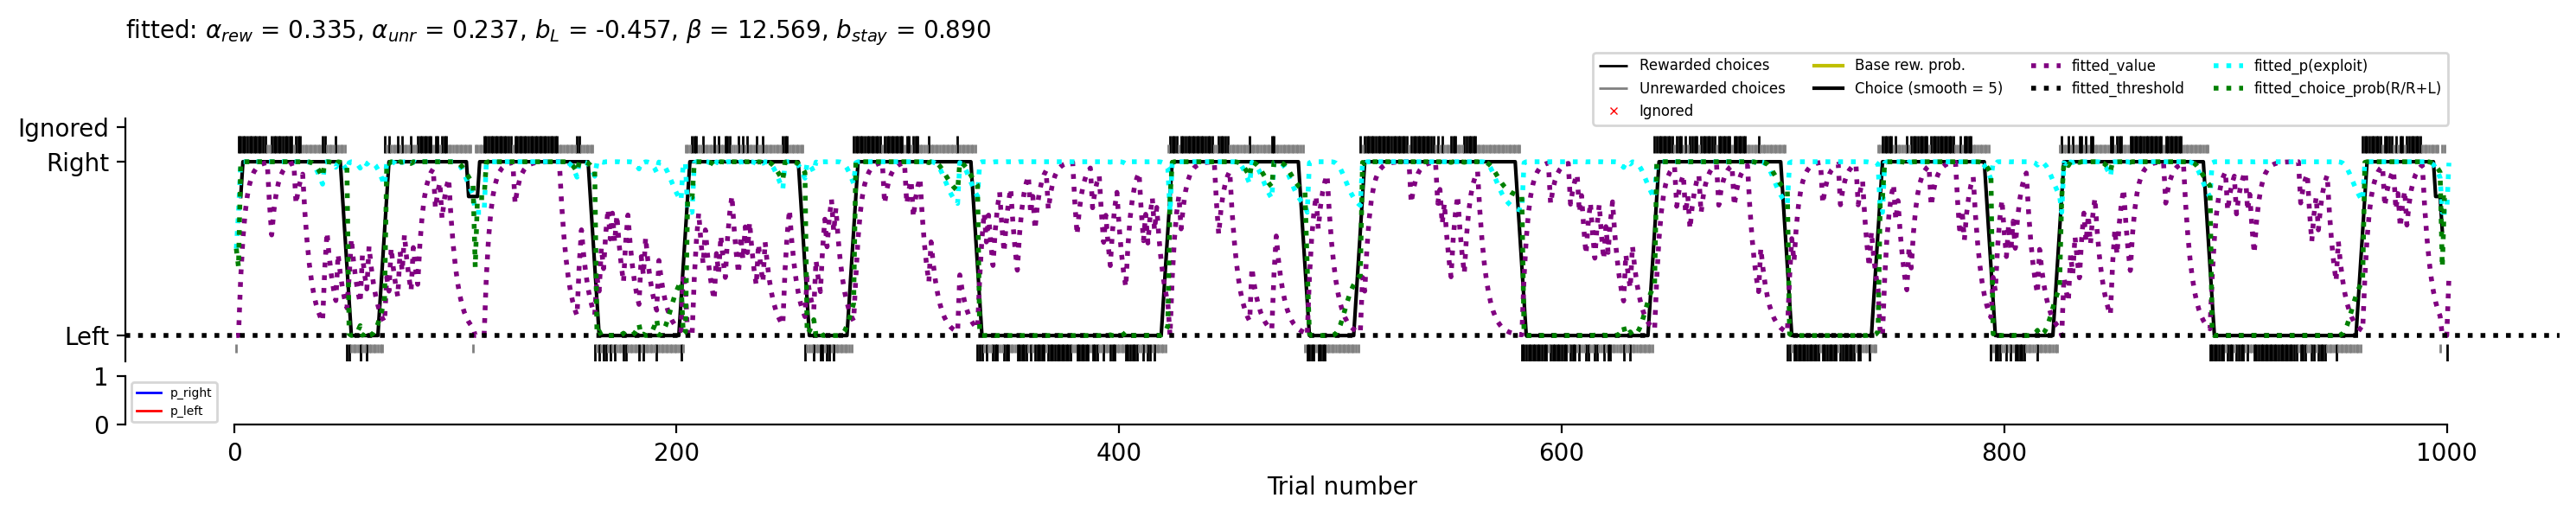

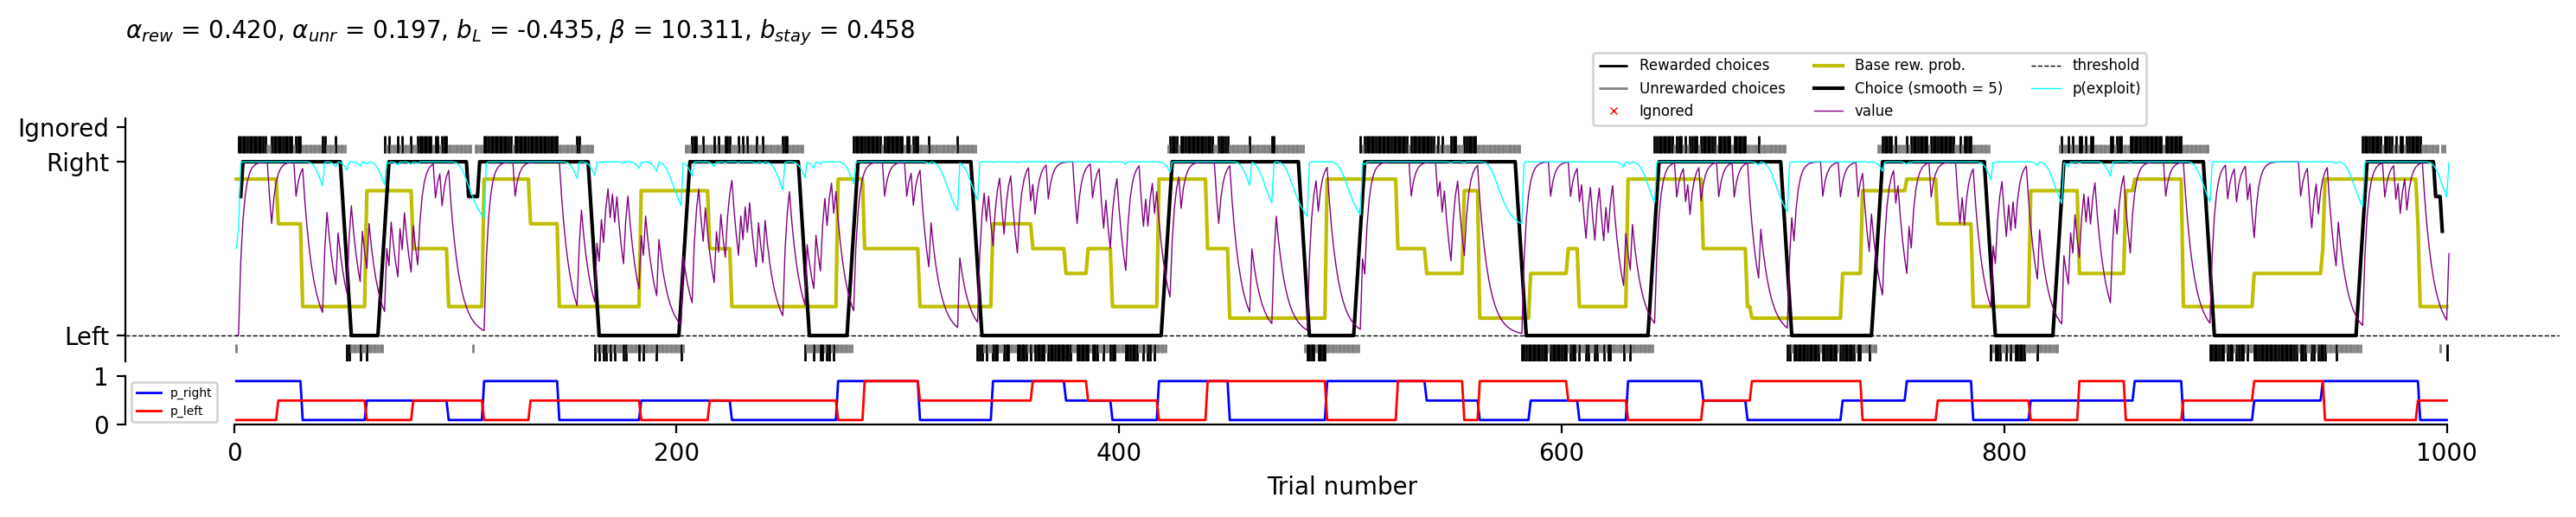

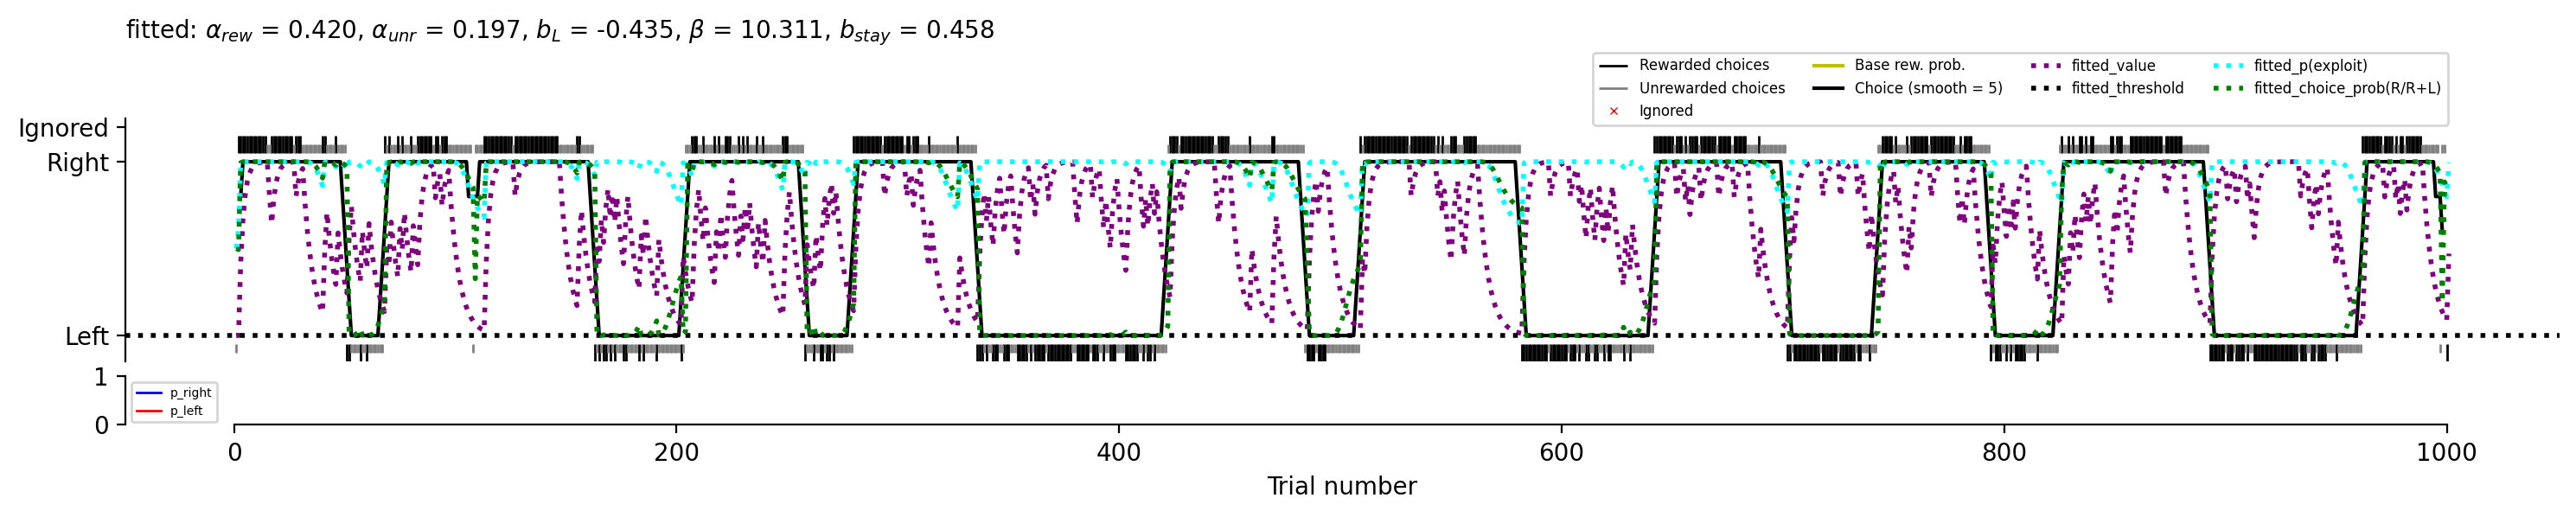

In [19]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1) Print Ground Truth Once (robust)
# --------------------------------------------------
print("\n================ GROUND TRUTH ================\n")
print(f"Ground-truth agent: {forager_gen.get_agent_alias()}")

# Prefer params dict from the agent itself if available
if "ground_truth_params" in globals() and isinstance(ground_truth_params, dict):
    gt_params_base = dict(ground_truth_params)
else:
    gt_params_base = dict(forager_gen.params.model_dump())

# IMPORTANT: merge in applied_gt so bias key/value is not lost
# (applied_gt is the dict returned by _set_ground_truth_params)
gt_params = dict(gt_params_base)
if "applied_gt" in globals() and isinstance(applied_gt, dict):
    gt_params.update(applied_gt)

print(f"Ground-truth params: {gt_params}")

# Also show agent_kwargs (useful when threshold is fixed, etc.)
print(f"Ground-truth agent_kwargs: {getattr(forager_gen, 'agent_kwargs', {})}")
print("\n")


# --------------------------------------------------
# 2) Plot sessions for ALL fitted variants (robust)
# --------------------------------------------------
task_for_plot = getattr(forager_gen, "task", None)

for r in results:
    agent = r["agent"]

    # Ensure agent has a task for plotting
    if task_for_plot is not None:
        agent.task = task_for_plot

    print("\n" + "-" * 80)
    print(f"Plotting fitted variant: {r['agent_alias']}")

    # plot_session may fail if the agent wasn't run on a task
    try:
        fig_fit, axes_fit = agent.plot_session(if_plot_latent=True)
    except Exception as e:
        print(f"[WARN] plot_session failed for {r['agent_alias']}: {type(e).__name__}: {e}")

    # plot_fitted_session usually works after fit
    try:
        fig_fitting, axes = agent.plot_fitted_session(if_plot_latent=True)
    except Exception as e:
        print(f"[WARN] plot_fitted_session failed for {r['agent_alias']}: {type(e).__name__}: {e}")


# --------------------------------------------------
# 3) Build Comparison DataFrame (align by fit_names)
# --------------------------------------------------
rows = []

# Collect union of fit parameter names across fitted models
all_param_names = set()
for r in results:
    fr = r["agent"].fitting_result
    fit_names = fr.fit_settings.get("fit_names", [])
    all_param_names.update(list(fit_names))

all_param_names = sorted(all_param_names)

# ---- Ground Truth Row ----
gt_row = {
    "agent_alias": "GROUND_TRUTH",
    "number_of_learning_rate": GT_number_of_learning_rate,
    "reset_to_threshold": GT_reset_to_threshold,
    "LPT": np.nan,
    "prediction_accuracy": np.nan,
}

# Fill ground-truth values using merged gt_params (includes applied_gt)
for name in all_param_names:
    gt_row[f"Fit_{name}"] = float(gt_params[name]) if name in gt_params else np.nan

rows.append(gt_row)

# ---- Fitted Model Rows ----
for r in results:
    agent = r["agent"]
    fr = agent.fitting_result

    row = {
        "agent_alias": r["agent_alias"],
        "number_of_learning_rate": r["number_of_learning_rate"],
        "reset_to_threshold": r["reset_to_threshold"],
        "LPT": float(fr.LPT),
        "prediction_accuracy": float(fr.prediction_accuracy),
    }

    fit_names = list(fr.fit_settings.get("fit_names", []))

    # Map name -> fitted value
    fitted_map = {n: float(v) for n, v in zip(fit_names, fr.x)}

    for name in all_param_names:
        row[f"Fit_{name}"] = fitted_map.get(name, np.nan)

    rows.append(row)

comparison_df = (
    pd.DataFrame(rows)
    .sort_values("LPT", ascending=False, na_position="first")
    .reset_index(drop=True)
)

comparison_df